
# Notebook 4 — Harlow's Downside Risk vs. the AVaR-Efficient Frontier

This notebook compares the AVaR-efficient frontier of Chapter 3 against
Harlow's lower-partial-moment (LPM) efficient frontier (Section 2.6),
consistent with Remark 2.1: LPM is convex but not, for a fixed target, a
monetary risk measure in the sense of Chapter 2, and is used here purely
as an empirical benchmark, exactly as in Harlow's own pre-axiomatic
motivation.

We compare the two frontiers under (i) Gaussian returns, where LPM$_2$
relative to a fixed target coincides at the optimum with (half) the
portfolio's own variance and should track Markowitz/AVaR closely, and
(ii) skewed returns, where the three criteria (AVaR, LPM, variance) can
disagree.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from convexrisk.mono_period import avar_efficient_frontier
from convexrisk.markowitz import markowitz_portfolio
from convexrisk.downside_risk import harlow_efficient_portfolio, lower_partial_moment

plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(11)



## 1. Gaussian returns: the three frontiers track each other


In [2]:

mu = np.array([0.09, 0.05])
sigma = np.array([[0.05, 0.015], [0.015, 0.03]])
level = 0.05
n_scenarios = 20000

scenario_returns = rng.multivariate_normal(mu, sigma, size=n_scenarios)
scenario_probs = np.full(n_scenarios, 1.0 / n_scenarios)

targets = np.linspace(0.01, 0.08, 8)

avar_results = avar_efficient_frontier(scenario_returns, scenario_probs, level, targets)
avar_pis = [r["pi"] for r in avar_results if r["success"]]

harlow_pis = []
for t in targets:
    res = harlow_efficient_portfolio(scenario_returns, scenario_probs, target_return=t,
                                      order=2.0, lpm_target=t)
    harlow_pis.append(res["pi"])

markowitz_pis = [markowitz_portfolio(mu, sigma, t) for t in targets]

weight_error_avar_markowitz = np.array([
    np.linalg.norm(a - m) / np.linalg.norm(m) for a, m in zip(avar_pis, markowitz_pis)
])
weight_error_harlow_markowitz = np.array([
    np.linalg.norm(h - m) / np.linalg.norm(m) for h, m in zip(harlow_pis, markowitz_pis)
])

print("Gaussian case -- relative weight error vs. Markowitz:")
print(f"  AVaR frontier:   mean={weight_error_avar_markowitz.mean()*100:.2f}%")
print(f"  Harlow frontier: mean={weight_error_harlow_markowitz.mean()*100:.2f}%")


Gaussian case -- relative weight error vs. Markowitz:
  AVaR frontier:   mean=5.14%
  Harlow frontier: mean=4.44%



## 2. Skewed returns: the three criteria can disagree

We again replace asset 1's marginal by a left-skewed distribution with
matched mean/variance (as in Notebook 1), and compare the same three
frontiers' portfolio weights.


In [3]:

skew_shape = -8.0
skewnorm = stats.skewnorm(a=skew_shape)
sn_mean, sn_var = skewnorm.stats(moments="mv")
sn_std = np.sqrt(sn_var)

corr = sigma / np.sqrt(np.diag(sigma))[:, None] / np.sqrt(np.diag(sigma))[None, :]
z = rng.multivariate_normal(np.zeros(2), corr, size=n_scenarios)
u1 = stats.norm.cdf(z[:, 0])
skewed_asset1 = skewnorm.ppf(np.clip(u1, 1e-6, 1 - 1e-6))
skewed_asset1 = mu[0] + np.sqrt(sigma[0, 0]) * (skewed_asset1 - sn_mean) / sn_std

scenario_returns_skewed = scenario_returns.copy()
scenario_returns_skewed[:, 0] = skewed_asset1

avar_results_sk = avar_efficient_frontier(scenario_returns_skewed, scenario_probs, level, targets)
avar_pis_sk = [r["pi"] for r in avar_results_sk if r["success"]]

harlow_pis_sk = []
for t in targets:
    res = harlow_efficient_portfolio(scenario_returns_skewed, scenario_probs, target_return=t,
                                      order=2.0, lpm_target=t)
    harlow_pis_sk.append(res["pi"])

markowitz_pis_sk = [markowitz_portfolio(mu, sigma, t) for t in targets]  # unchanged: only 1st/2nd moments

weight_error_avar_markowitz_sk = np.array([
    np.linalg.norm(a - m) / np.linalg.norm(m) for a, m in zip(avar_pis_sk, markowitz_pis_sk)
])
weight_error_harlow_avar_sk = np.array([
    np.linalg.norm(h - a) / np.linalg.norm(a) for h, a in zip(harlow_pis_sk, avar_pis_sk)
])

print("Skewed case -- relative weight errors:")
print(f"  AVaR vs. Markowitz:   mean={weight_error_avar_markowitz_sk.mean()*100:.1f}%")
print(f"  Harlow vs. AVaR:      mean={weight_error_harlow_avar_sk.mean()*100:.1f}%")


Skewed case -- relative weight errors:
  AVaR vs. Markowitz:   mean=46.6%
  Harlow vs. AVaR:      mean=11.3%


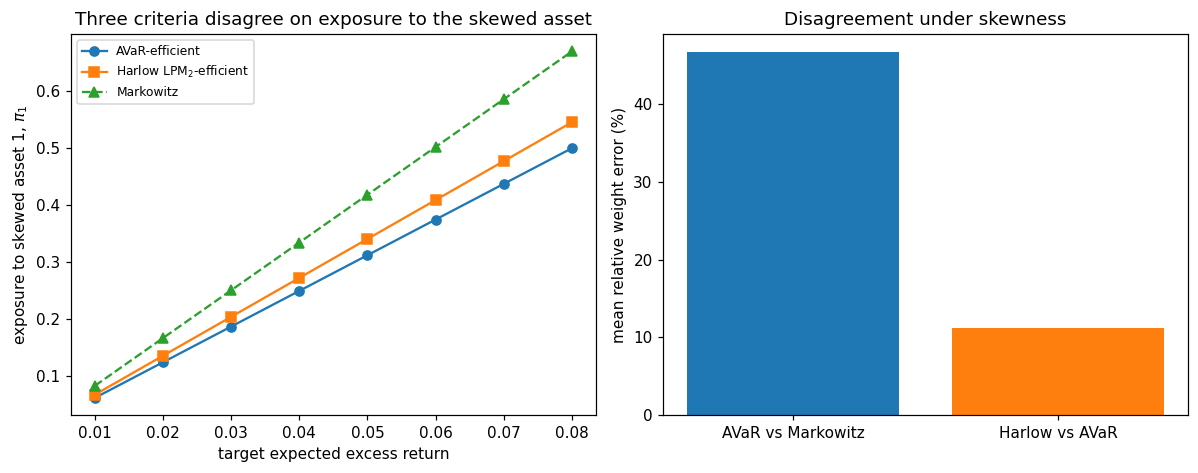

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

pi1_avar = [p[0] for p in avar_pis_sk]
pi1_harlow = [p[0] for p in harlow_pis_sk]
pi1_markowitz = [p[0] for p in markowitz_pis_sk]

axes[0].plot(targets, pi1_avar, "o-", label="AVaR-efficient", color="C0")
axes[0].plot(targets, pi1_harlow, "s-", label="Harlow LPM$_2$-efficient", color="C1")
axes[0].plot(targets, pi1_markowitz, "^--", label="Markowitz", color="C2")
axes[0].set_xlabel("target expected excess return")
axes[0].set_ylabel(r"exposure to skewed asset 1, $\pi_1$")
axes[0].set_title("Three criteria disagree on exposure to the skewed asset")
axes[0].legend(fontsize=8)

axes[1].bar(["AVaR vs Markowitz", "Harlow vs AVaR"],
            [weight_error_avar_markowitz_sk.mean() * 100, weight_error_harlow_avar_sk.mean() * 100],
            color=["C0", "C1"])
axes[1].set_ylabel("mean relative weight error (%)")
axes[1].set_title("Disagreement under skewness")

plt.tight_layout()
plt.savefig("fig_04_harlow_vs_avar_skewed.png", dpi=140)
plt.show()



## Summary

Under Gaussian returns all three criteria (AVaR, Harlow LPM$_2$,
Markowitz) essentially agree, consistent with Theorem 3.1's mechanism
and its analogue for a fixed-target LPM$_2$. Once a genuine left skew is
introduced in one asset, the three criteria allocate meaningfully
differently to that asset — variance and (target-relative) LPM$_2$ both
remain blind to the asymmetry beyond the second moment in ways that
$\mathrm{AVaR}_\lambda$ is specifically designed to capture, confirming
Remark 2.1's positioning of Harlow's criterion as a convex but
non-coherent empirical benchmark rather than a substitute for the
axiomatic theory of Chapter 2.
